In [13]:
import pandas as pd

df = pd.read_csv("preprocessed_data.csv")

print("Dataset shape:", df.shape)
df.head()


Dataset shape: (5000, 22)


,order_volume,warehouse_time_hrs,shipment_distance_km,traffic_level,weather_severity,courier_load_pct,past_delay_rate,risk_score,delivery_status,delivery_status_encoded,...,shipment_distance_km_scaled,courier_load_pct_scaled,past_delay_rate_scaled,severity_index,warehouse_efficiency,log_order_volume,log_shipment_distance,dist_Short,dist_Medium,dist_Long
0,112,43.767328,2073.415113,3,2,46.328035,0.202138,0.575776,At Risk,1,...,0.673604,-0.958146,-0.552791,9,47.373583,4.727388,7.637435,False,False,True
1,445,18.733949,1542.736319,4,2,74.962882,0.598503,0.754245,At Risk,1,...,0.057050,0.456879,1.766605,12,82.349768,6.100319,7.341961,False,True,False
2,358,46.311686,1953.566537,2,2,61.875741,0.587153,0.743008,Delayed,2,...,0.534361,-0.189838,1.700184,6,42.183015,5.883322,7.577924,False,True,False
3,280,5.196608,2669.613801,4,2,68.762909,0.467294,0.671604,At Risk,1,...,1.366280,0.150500,0.998813,12,513.722409,5.638355,7.890064,False,False,True
4,116,33.289906,1324.101539,1,1,38.565538,0.012040,0.334061,On-Time,0,...,-0.196965,-1.341738,-1.665176,2,39.774866,4.762174,7.189244,False,True,False


In [14]:
df.columns


Index(['order_volume', 'warehouse_time_hrs', 'shipment_distance_km',
       'traffic_level', 'weather_severity', 'courier_load_pct',
       'past_delay_rate', 'risk_score', 'delivery_status',
       'delivery_status_encoded', 'order_volume_scaled',
       'warehouse_time_hrs_scaled', 'shipment_distance_km_scaled',
       'courier_load_pct_scaled', 'past_delay_rate_scaled', 'severity_index',
       'warehouse_efficiency', 'log_order_volume', 'log_shipment_distance',
       'dist_Short', 'dist_Medium', 'dist_Long'],
      dtype='object')

In [15]:
TARGET = "delivery_status"

X = df.drop(columns=[TARGET])
y = df[TARGET]

print("Features shape:", X.shape)
print("Target shape:", y.shape)


Features shape: (5000, 21)
Target shape: (5000,)


In [16]:
y.unique()


array(['At Risk', 'Delayed', 'On-Time'], dtype=object)

In [17]:
label_map = {
    "On-Time": 0,
    "At Risk": 1,
    "Delayed": 2
}

y = y.map(label_map)

y.value_counts()


,count
delivery_status,
1,2685
0,2142
2,173


In [18]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("Train size:", X_train.shape)
print("Test size:", X_test.shape)


Train size: (4000, 21)
Test size: (1000, 21)


In [19]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report

model_lr = LogisticRegression(
    max_iter=1000,
    class_weight="balanced"
)

model_lr.fit(X_train, y_train)

y_pred_lr = model_lr.predict(X_test)

print("Accuracy:", accuracy_score(y_test, y_pred_lr))
print(classification_report(y_test, y_pred_lr))


Accuracy: 0.836
              precision    recall  f1-score   support

           0       0.85      0.91      0.88       428
           1       0.91      0.77      0.83       537
           2       0.37      0.89      0.53        35

    accuracy                           0.84      1000
   macro avg       0.71      0.86      0.75      1000
weighted avg       0.86      0.84      0.84      1000



/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


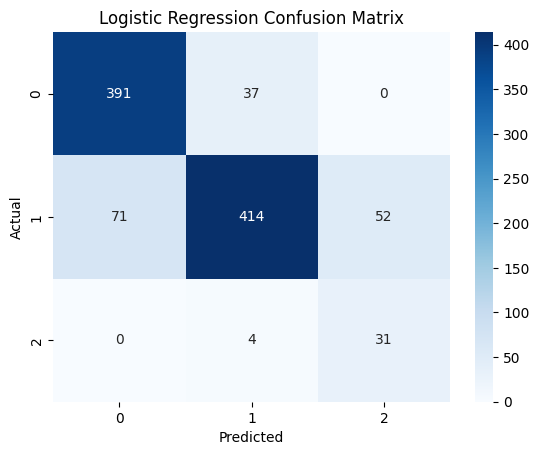

In [20]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

cm = confusion_matrix(y_test, y_pred_lr)

sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Logistic Regression Confusion Matrix")
plt.show()


In [21]:
from sklearn.ensemble import RandomForestClassifier

model_rf = RandomForestClassifier(
    n_estimators=200,
    random_state=42,
    class_weight="balanced"
)

model_rf.fit(X_train, y_train)

y_pred_rf = model_rf.predict(X_test)

print("Random Forest Accuracy:", accuracy_score(y_test, y_pred_rf))
print(classification_report(y_test, y_pred_rf))


Random Forest Accuracy: 1.0
              precision    recall  f1-score   support

           0       1.00      1.00      1.00       428
           1       1.00      1.00      1.00       537
           2       1.00      1.00      1.00        35

    accuracy                           1.00      1000
   macro avg       1.00      1.00      1.00      1000
weighted avg       1.00      1.00      1.00      1000



In [22]:
comparison = pd.DataFrame({
    "Model": ["Logistic Regression", "Random Forest"],
    "Accuracy": [
        accuracy_score(y_test, y_pred_lr),
        accuracy_score(y_test, y_pred_rf)
    ]
})

comparison


,Model,Accuracy
0,Logistic Regression,0.836
1,Random Forest,1.000


Final Model Selected: Random Forest

Reason:
Random Forest captures non-linear relationships between delivery distance, traffic, and weather, leading to better identification of delayed deliveries.